# 2D Velocity Profile Line Extraction

Extract velocity, depth, and terrain along a user-defined profile line from a completed 2D plan HDF.

In [1]:
import logging
from pathlib import Path
import os

logging.getLogger("numexpr").setLevel(logging.WARNING)
logging.getLogger("numexpr.utils").setLevel(logging.WARNING)

import h5py
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import numpy as np
from shapely.geometry import LineString

from ras_commander import HdfResultsQuery

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Locate Completed Bald Eagle Results

In [2]:
def candidate_result_dirs():
    env_path = os.environ.get("RAS_COMMANDER_BALD_EAGLE_RESULTS")
    if env_path:
        yield Path(env_path)
    yield Path("H:/Symphony/RASDecomp/CLB-850/inputs/BaldEagleCrkMulti2D_722_gridded")

    workspace = Path.cwd()
    for root in [workspace, *workspace.parents[:3]]:
        yield root / "example_projects" / "BaldEagleCrkMulti2D_velocity"
        yield root / "examples" / "example_projects" / "BaldEagleCrkMulti2D_AORC_2020_901"


def find_plan_hdf():
    for result_dir in candidate_result_dirs():
        if not result_dir.exists():
            continue
        for plan_hdf in sorted(result_dir.glob("BaldEagleDamBrk.p*.hdf")):
            with h5py.File(plan_hdf, "r") as hdf:
                if "Geometry/2D Flow Areas/Attributes" not in hdf:
                    continue
                mesh_name = hdf["Geometry/2D Flow Areas/Attributes"][()]["Name"][0].decode().strip()
                face_velocity_path = (
                    "Results/Unsteady/Output/Output Blocks/Base Output/"
                    f"Unsteady Time Series/2D Flow Areas/{mesh_name}/Face Velocity"
                )
                if face_velocity_path in hdf:
                    return plan_hdf, mesh_name
    raise FileNotFoundError(
        "Completed Bald Eagle result HDF not found. Set "
        "RAS_COMMANDER_BALD_EAGLE_RESULTS to a folder containing BaldEagleDamBrk.p##.hdf."
    )


plan_hdf, mesh_name = find_plan_hdf()
print(f"Using {plan_hdf.name} from {plan_hdf.parent.name}; mesh={mesh_name}")

Using BaldEagleDamBrk.p06.hdf from BaldEagleCrkMulti2D_415; mesh=BaldEagleCr


## Build A Profile Line Through Peak Face Velocity

In [3]:
with h5py.File(plan_hdf, "r") as hdf:
    base_geom = f"Geometry/2D Flow Areas/{mesh_name}"
    face_velocity_path = (
        "Results/Unsteady/Output/Output Blocks/Base Output/"
        f"Unsteady Time Series/2D Flow Areas/{mesh_name}/Face Velocity"
    )
    face_velocity = np.asarray(hdf[face_velocity_path][()])
    time_index = int(np.nanargmax(np.nanmax(np.abs(face_velocity), axis=1)))
    peak_face_id = int(np.nanargmax(np.abs(face_velocity[time_index])))
    face_cells = np.asarray(hdf[f"{base_geom}/Faces Cell Indexes"][peak_face_id])
    seed_cell = int(face_cells[face_cells >= 0][0])
    seed_xy = np.asarray(hdf[f"{base_geom}/Cells Center Coordinate"][seed_cell], dtype=float)

profile_line = LineString([
    (float(seed_xy[0] - 1000.0), float(seed_xy[1])),
    (float(seed_xy[0] + 1000.0), float(seed_xy[1])),
])

profile = HdfResultsQuery.query_polyline_velocity_profile(
    plan_hdf,
    profile_line,
    time_index=time_index,
    sample_spacing=100.0,
)
wet_profile = profile[profile["mesh_name"].notna()].copy()
if wet_profile.empty:
    raise RuntimeError("Profile line did not intersect wet 2D mesh output.")

profile.head()

,station,x,y,mesh_name,face_id,velocity_x,velocity_y,velocity_mag,depth,terrain_elev
0,0.000000,2.005000e+06,324500.0,BaldEagleCr,27546,NaN,NaN,NaN,NaN,637.542236
1,0.000000,2.005000e+06,324500.0,BaldEagleCr,27546,NaN,NaN,NaN,NaN,637.542236
2,24.535303,2.005025e+06,324500.0,BaldEagleCr,27548,NaN,NaN,NaN,NaN,637.844116
3,44.535305,2.005045e+06,324500.0,BaldEagleCr,27548,NaN,NaN,NaN,NaN,638.428528
4,64.535301,2.005065e+06,324500.0,BaldEagleCr,27548,NaN,NaN,NaN,NaN,639.644104


## Plot Velocity Against Terrain

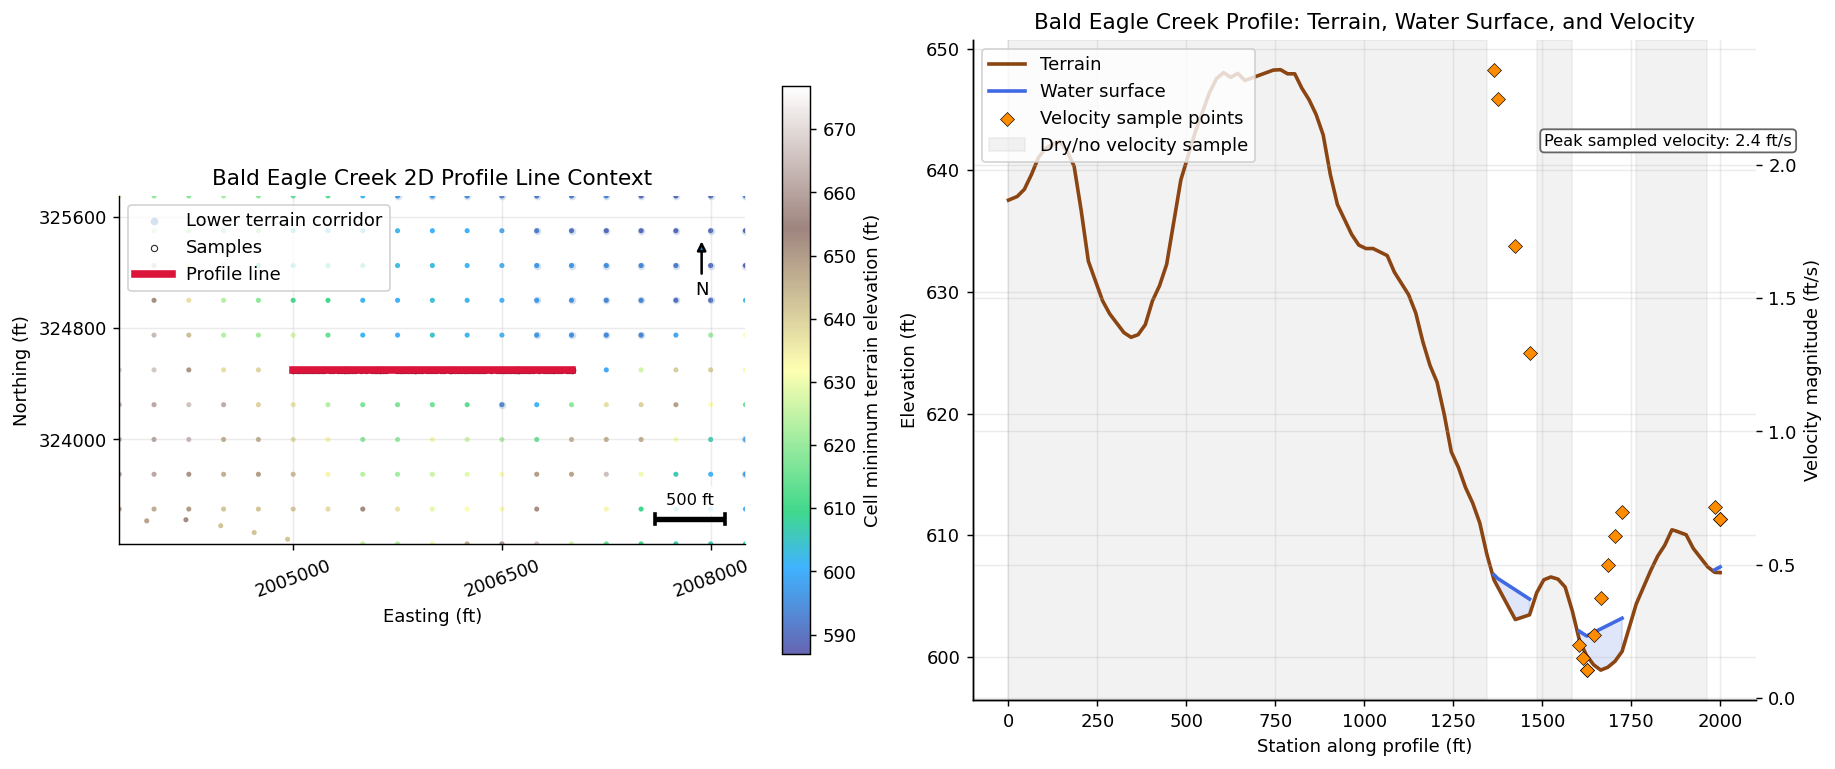

In [4]:
with h5py.File(plan_hdf, "r") as hdf:
    base_geom = f"Geometry/2D Flow Areas/{mesh_name}"
    centers = np.asarray(hdf[f"{base_geom}/Cells Center Coordinate"][()], dtype=float)
    cell_min = np.asarray(hdf[f"{base_geom}/Cells Minimum Elevation"][()], dtype=float)

pad = 1250.0
xmin, ymin, xmax, ymax = profile_line.bounds
near_mask = (
    (centers[:, 0] >= xmin - pad)
    & (centers[:, 0] <= xmax + pad)
    & (centers[:, 1] >= ymin - pad)
    & (centers[:, 1] <= ymax + pad)
)

fig, (ax_map, ax_profile) = plt.subplots(
    1,
    2,
    figsize=(14.0, 5.8),
    gridspec_kw={"width_ratios": [1.0, 1.25]},
    constrained_layout=True,
)

low_terrain_threshold = np.nanpercentile(cell_min[near_mask], 20.0)
low_terrain_mask = near_mask & (cell_min <= low_terrain_threshold)
ax_map.scatter(
    centers[low_terrain_mask, 0],
    centers[low_terrain_mask, 1],
    s=18,
    color="steelblue",
    alpha=0.22,
    linewidths=0,
    label="Lower terrain corridor",
)
terrain_scatter = ax_map.scatter(
    centers[near_mask, 0],
    centers[near_mask, 1],
    c=cell_min[near_mask],
    s=8,
    cmap="terrain",
    alpha=0.75,
    linewidths=0,
)
ax_map.scatter(wet_profile["x"], wet_profile["y"], s=12, facecolors="white", edgecolors="black", linewidths=0.6, alpha=0.85, label="Samples", zorder=4)
line_x, line_y = profile_line.xy
ax_map.plot(line_x, line_y, color="crimson", linewidth=4.2, label="Profile line", zorder=6)
ax_map.annotate("N", xy=(0.93, 0.88), xytext=(0.93, 0.73), xycoords="axes fraction", ha="center", va="center", arrowprops={"arrowstyle": "-|>", "lw": 1.4})
ax_map.set_xlim(xmin - pad, xmax + pad)
ax_map.set_ylim(ymin - pad, ymax + pad)
scale_len = 500.0
scale_x0 = xmax + pad - scale_len - 150.0
scale_y0 = ymin - pad + 180.0
ax_map.plot([scale_x0, scale_x0 + scale_len], [scale_y0, scale_y0], color="black", linewidth=3.0, solid_capstyle="butt", zorder=5)
ax_map.plot([scale_x0, scale_x0], [scale_y0 - 35.0, scale_y0 + 35.0], color="black", linewidth=2.0, zorder=5)
ax_map.plot([scale_x0 + scale_len, scale_x0 + scale_len], [scale_y0 - 35.0, scale_y0 + 35.0], color="black", linewidth=2.0, zorder=5)
ax_map.text(scale_x0 + scale_len / 2.0, scale_y0 + 80.0, "500 ft", ha="center", va="bottom", fontsize=9, bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85})
ax_map.set_title("Bald Eagle Creek 2D Profile Line Context")
ax_map.set_xlabel("Easting (ft)")
ax_map.set_ylabel("Northing (ft)")
ax_map.set_aspect("equal", adjustable="box")
for axis in (ax_map.xaxis, ax_map.yaxis):
    formatter = ScalarFormatter(useOffset=False)
    formatter.set_scientific(False)
    axis.set_major_formatter(formatter)
    axis.set_major_locator(MaxNLocator(nbins=4))
ax_map.tick_params(axis="x", labelrotation=20)
ax_map.legend(loc="upper left", frameon=True)
cbar = fig.colorbar(terrain_scatter, ax=ax_map, shrink=0.86)
cbar.set_label("Cell minimum terrain elevation (ft)")

station = wet_profile["station"].to_numpy(dtype=float)
terrain = wet_profile["terrain_elev"].to_numpy(dtype=float)
water_surface = terrain + wet_profile["depth"].to_numpy(dtype=float)
velocity_mag = wet_profile["velocity_mag"].to_numpy(dtype=float)
missing_velocity = ~np.isfinite(velocity_mag)
gap_patch = None
if np.any(missing_velocity):
    gap_indexes = np.flatnonzero(missing_velocity)
    gap_groups = np.split(gap_indexes, np.where(np.diff(gap_indexes) > 1)[0] + 1)
    for gap_group in gap_groups:
        if len(gap_group) == 0:
            continue
        start_station = float(station[gap_group[0]])
        end_station = float(station[gap_group[-1]])
        if np.isclose(start_station, end_station):
            end_station = start_station + 20.0
        span = ax_profile.axvspan(start_station, end_station, color="0.82", alpha=0.28, label="Dry/no velocity sample" if gap_patch is None else None)
        if gap_patch is None:
            gap_patch = span
drop_patch = None
if len(station) > 1:
    drop_idx = int(np.nanargmin(np.diff(terrain)))
    drop_station0 = float(station[drop_idx])
    drop_station1 = float(station[drop_idx + 1])
    terrain_drop = float(terrain[drop_idx] - terrain[drop_idx + 1])
    if terrain_drop > 5.0:
        drop_patch = ax_profile.axvspan(drop_station0, drop_station1, color="gold", alpha=0.18, label="Steep terrain drop")

terrain_line, = ax_profile.plot(station, terrain, color="saddlebrown", linewidth=2.0, label="Terrain")
wse_line, = ax_profile.plot(station, water_surface, color="royalblue", linewidth=2.0, label="Water surface")
ax_profile.fill_between(station, terrain, water_surface, color="royalblue", alpha=0.16)
ax_profile.set_title("Bald Eagle Creek Profile: Terrain, Water Surface, and Velocity")
ax_profile.set_xlabel("Station along profile (ft)")
ax_profile.set_ylabel("Elevation (ft)")
if drop_patch is not None:
    ax_profile.annotate(
        f"Steep terrain drop\n{terrain_drop:.0f} ft over {drop_station1 - drop_station0:.0f} ft",
        xy=((drop_station0 + drop_station1) / 2.0, min(terrain[drop_idx], terrain[drop_idx + 1]) + 12.0),
        xytext=(drop_station1 + 130.0, min(terrain[drop_idx], terrain[drop_idx + 1]) + 34.0),
        arrowprops={"arrowstyle": "->", "color": "saddlebrown", "lw": 1.1},
        color="saddlebrown",
        fontsize=9,
        bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "saddlebrown", "alpha": 0.9},
    )

ax_velocity = ax_profile.twinx()
velocity_line = ax_velocity.scatter(station, velocity_mag, s=30, marker="D", color="darkorange", edgecolors="black", linewidths=0.35, label="Velocity sample points", zorder=5)
ax_velocity.set_ylabel("Velocity magnitude (ft/s)")
peak_idx = int(np.nanargmax(velocity_mag))
peak_station = float(station[peak_idx])
peak_velocity = float(velocity_mag[peak_idx])
ax_velocity.text(
    0.73,
    0.84,
    f"Peak sampled velocity: {peak_velocity:.1f} ft/s",
    transform=ax_velocity.transAxes,
    color="black",
    fontsize=9,
    bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "edgecolor": "0.35", "alpha": 0.92},
)

lines = [terrain_line, wse_line, velocity_line]
if drop_patch is not None:
    lines.append(drop_patch)
if gap_patch is not None:
    lines.append(gap_patch)
ax_profile.legend(lines, [line.get_label() for line in lines], loc="upper left", frameon=True)
plt.show()